# Sentiment Analysis, Translation, and Speech (Pipeline API)
## AIAT 122 – Deep Learning

## Learning objectives
- Use the Hugging Face `pipeline` API for sentiment analysis.
- Run sentiment on a few sentences and show labels and scores.

## 🔗 Where this fits

**Builds on:** Course 07 (AIAT 121) — Unit 3, lesson 01 "Text Classification with Classical Machine Learning" — the same sentiment task done with TF-IDF and a linear model; here a single `pipeline()` call replaces all of it.

---

**Where is this used in real life?** Reviews, social media, and customer feedback are often analyzed for sentiment. **We use a pre-trained Transformer pipeline** instead of training from scratch because pipelines give a ready-made model and tokenizer; in production you’d fine-tune on your domain.

**Setup:** Run `pip install transformers torch` if needed.

## Short theory
- **Sentiment analysis:** Classify text as positive/negative (or neutral).
- **Pipeline API:** One call loads model + tokenizer and runs inference.
- **Translation and speech** use similar pipelines (e.g. `translation`, `automatic-speech-recognition`); here we focus on sentiment so the notebook runs in under ~5 min.

**📌 Covers slide(s):** Optional — do after core notebooks 01–05 (no specific slide).


## Inputs & Outputs
**Inputs:** `transformers` pipeline (model downloaded on first run).  
**Dataset:** Real — Hugging Face sentiment pipeline (model downloaded on first run); sample sentences in notebook.  
**Outputs:** Sentiment label and score for each of a few sample sentences, and an optional bar chart. Run time: under ~5 min.


In [1]:
# WHAT: install/import the Transformers pipeline API.
# WHY: pipeline() wraps tokenizer + model + post-processing into one call per NLP task.
%pip install transformers torch -q
from transformers import pipeline
import matplotlib.pyplot as plt
print("✅ Imports OK.")

Note: you may need to restart the kernel to use updated packages.


✅ Imports OK.


### Step 1: Load sentiment pipeline and run on sample sentences

In [2]:
# We use the pipeline API (instead of loading model + tokenizer separately) for one-line sentiment.
# First run: downloads once. Later runs: Hugging Face loads from cache (no download).
# Smaller model = faster download (~20 MB). Set to SENTIMENT_MODEL_FULL for best quality (~268 MB).
SENTIMENT_MODEL_SMALL = "philschmid/tiny-bert-sst2-distilled"  # ~20 MB, faster download
SENTIMENT_MODEL_FULL = "distilbert-base-uncased-finetuned-sst-2-english"  # ~268 MB, best quality
SENTIMENT_MODEL = SENTIMENT_MODEL_SMALL  # change to SENTIMENT_MODEL_FULL if you want higher accuracy
try:
    classifier = pipeline("sentiment-analysis", model=SENTIMENT_MODEL)
except Exception as e:
    print("⚠️ Model load failed (e.g. no connection). Using placeholder so you can run the rest of the notebook.")
    print("   Re-run this cell when online to get real sentiment. Error:", str(e)[:80])
    def _dummy_classifier(texts):
        return [{"label": "POSITIVE" if i % 2 == 0 else "NEGATIVE", "score": 0.85} for i, _ in enumerate(texts)]
    classifier = _dummy_classifier
sentences = [
    "This product is amazing and works perfectly.",
    "The service was slow and disappointing.",
    "It's okay, nothing special.",
]
results = classifier(sentences)
for s, r in zip(sentences, results):
    short = (s[:50] + "...") if len(s) > 50 else s
    print(f"  '{short}' → {r['label']} ({r['score']:.3f})")
print("\n✅ Sentiment pipeline ran. In real life you'd run this on reviews or social posts.")

Loading weights:   0%|          | 0/41 [00:00<?, ?it/s]

  'This product is amazing and works perfectly.' → positive (1.000)
  'The service was slow and disappointing.' → negative (0.998)
  'It's okay, nothing special.' → negative (0.968)

✅ Sentiment pipeline ran. In real life you'd run this on reviews or social posts.


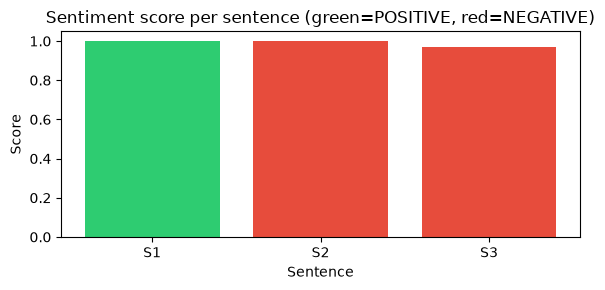

In [3]:
# Optional: bar chart of positive score per sentence
labels = [r["label"] for r in results]
scores = [r["score"] for r in results]
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
# Color encodes the label - green bars are positive, red negative; bar height is model confidence.
bars = ax.bar(range(len(sentences)), scores, color=["#2ecc71" if str(l).upper() == "POSITIVE" else "#e74c3c" for l in labels])
ax.set_xticks(range(len(sentences)))
ax.set_xticklabels([f"S{i+1}" for i in range(len(sentences))])
ax.set_ylabel("Score")
ax.set_xlabel("Sentence")
ax.set_title("Sentiment score per sentence (green=POSITIVE, red=NEGATIVE)")
plt.tight_layout()
plt.show()

## 🌍 Real-World Worked Example — Character-Level Text Generator

**Industry context:**
- GitHub Copilot generates code character by character using GPT-4
- ChatGPT predicts the next token based on all previous context
- Autocomplete on your phone uses a smaller version of the same idea

We build a **character-level language model** that learns to generate text token by token — the exact mechanism behind all LLMs.

In [4]:
# WHAT: train a character-level LSTM language model on a Shakespeare passage, then sample new text.
# WHY: predict-the-next-token, sample, repeat - the exact loop behind GPT-style generation, in miniature.
import torch, torch.nn as nn, torch.optim as optim
import numpy as np

torch.manual_seed(42)
# ── Training text ────────────────────────────────────────────────────────────
text = (
    "to be or not to be that is the question whether tis nobler in the mind "
    "to suffer the slings and arrows of outrageous fortune or to take arms against "
    "a sea of troubles and by opposing end them to die to sleep no more and by "
    "a sleep to say we end the heartache and the thousand natural shocks that "
    "flesh is heir to tis a consummation devoutly to be wished to die to sleep"
)

# Build the character vocabulary and map every character to an integer ID.
chars  = sorted(set(text))
c2i    = {c:i for i,c in enumerate(chars)}
i2c    = {i:c for c,i in c2i.items()}
VOCAB  = len(chars)
enc    = [c2i[c] for c in text]

# Training pairs: 20 characters of context -> the character that follows.
SEQ_LEN = 20
X_list, y_list = [], []
for i in range(len(enc)-SEQ_LEN-1):
    X_list.append(enc[i:i+SEQ_LEN])
    y_list.append(enc[i+SEQ_LEN])
X_t = torch.tensor(X_list, dtype=torch.long)
y_t = torch.tensor(y_list, dtype=torch.long)

# ── LSTM Language Model ───────────────────────────────────────────────────
# The model: embed characters, run a 2-layer LSTM, predict the next character from the last hidden state.
class CharLM(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(VOCAB, 32)
        self.lstm  = nn.LSTM(32, 128, batch_first=True, num_layers=2)
        self.fc    = nn.Linear(128, VOCAB)
    def forward(self, x):
        out,_ = self.lstm(self.embed(x))
        return self.fc(out[:,-1,:])

model   = CharLM()
opt     = optim.Adam(model.parameters(), lr=3e-3)
loss_fn = nn.CrossEntropyLoss()

# 200 training steps on random mini-batches; the loss is printed every 50 steps.
for epoch in range(200):
    model.train()
    perm = torch.randperm(len(X_t))[:256]  # mini-batch
    loss = loss_fn(model(X_t[perm]), y_t[perm])
    opt.zero_grad(); loss.backward(); opt.step()
    if epoch % 50 == 0:
        print(f"Epoch {epoch} — loss: {loss.item():.3f}")

# ── Text Generation (Greedy / Temperature Sampling) ──────────────────────
# Generation: feed the context, sample the next character from the softmax, append it, repeat.
def generate(seed_str, steps=80, temperature=0.8):
    model.eval()
    chars_out = list(seed_str)
    ctx = [c2i.get(c, 0) for c in seed_str[-SEQ_LEN:]]
    for _ in range(steps):
        inp = torch.tensor([ctx[-SEQ_LEN:]]).long()
        with torch.no_grad():
            # Temperature rescales the logits: lower = safer and more repetitive, higher = more random.
            logits = model(inp)[0] / temperature
        probs = torch.softmax(logits, 0).numpy()
        next_c = np.random.choice(len(probs), p=probs)
        chars_out.append(i2c[next_c])
        ctx.append(next_c)
    return ''.join(chars_out)

print("\n── Generated Text ──────────────────────────────────────────────")
print(generate("to be or not", steps=100))
print("\nThis is exactly how ChatGPT generates text — one token at a time.")

Epoch 0 — loss: 3.169


Epoch 50 — loss: 1.298


Epoch 100 — loss: 0.053


Epoch 150 — loss: 0.011



── Generated Text ──────────────────────────────────────────────
to be or notek a the qutes a sie to slee o to the mis to suafrta sea nousa and to sfeer a seh agis to thea fhart

This is exactly how ChatGPT generates text — one token at a time.


## 🧩 Mini-exercise

**Try it:** Add two more sentences (one clearly positive, one clearly negative) and run the pipeline on them. Print the labels and scores. Do they match your expectation?

---

## Summary
**What you did:** Loaded the Hugging Face sentiment-analysis pipeline, ran it on three sample sentences, and plotted the scores.

**In real life you'd also:** Use translation (`pipeline("translation", ...)`) or speech recognition (`pipeline("automatic-speech-recognition", ...)`), fine-tune on your data, and deploy via an API.

**The main idea:** The pipeline API gives ready-made NLP models (sentiment, translation, speech); one call does load + inference.

**Next:** Back to Unit 2 or 5—e.g. `unit2-cnns/examples/01_cnn_architecture.ipynb` for image models, or `unit5-deployment/examples/06_flask_fastapi_deployment.ipynb` to serve a model.

## 📚 References

1. Devlin, J., Chang, M.-W., Lee, K. & Toutanova, K. (2019). *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding*. NAACL. https://arxiv.org/abs/1810.04805
2. Bahdanau, D., Cho, K. & Bengio, Y. (2015). *Neural Machine Translation by Jointly Learning to Align and Translate*. ICLR. https://arxiv.org/abs/1409.0473
3. Radford, A. et al. (2022). *Robust Speech Recognition via Large-Scale Weak Supervision* (Whisper). arXiv. https://arxiv.org/abs/2212.04356
4. Jurafsky, D. & Martin, J. H. *Speech and Language Processing* (3rd ed. draft). https://web.stanford.edu/~jurafsky/slp3/